#### 5.1 Labelling PCs

In [1]:
#### 12.29.2025
#### 2 labelling changes in this notebook, then written to a new manual label folder
#### We're changing the Enterocyte label to Enterocyte Progenitor to better reflect the early timepoint.
#### Then, create a new .obs metadata column, and store a new 'Secretory PC' label, based on the expression of SOX4 in the PCs

#### Import python single cell stack

In [2]:
## Python single cell stack


import scanpy as sc

import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse import issparse

## Plotting

import matplotlib.pyplot as plt
import seaborn as sns

## Paths and system

import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR


#### Load in our object

In [3]:

d2_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "data-objects/labelled/d2_dz_manual_labels.h5ad")

In [4]:
d2_dz_clustered

AnnData object with n_obs × n_vars = 46210 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_labelled', 'manual_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'manual_label_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

#### Change the Enterocytes to Enterocyte PCs

In [5]:
## Check this is categorical
d2_dz_clustered.obs['manual_label'].dtype

CategoricalDtype(categories=['Enterocytes', 'ISCs', 'PCs', 'Proliferating PCs'], ordered=False, categories_dtype=object)

In [6]:
d2_dz_clustered.obs['manual_label'] = d2_dz_clustered.obs['manual_label'].cat.rename_categories({
    "Enterocytes": "Enterocyte PCs"
})

#### Create a new layer of metadata, for the Secretory PC label

In [7]:
d2_dz_clustered.obs['pc_manual_label'] = d2_dz_clustered.obs['manual_label'].copy()

#### Define a function for filtering based on gene expression 


In [8]:

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

#### Create a new 'Category', Secretory PCs, within the column

In [9]:
d2_dz_clustered.obs["pc_manual_label"] = (
    d2_dz_clustered.obs["pc_manual_label"]
    .cat
    .add_categories(["Secretory PCs"])
)

#### Complete the assignment

In [10]:
# Secretory PCs: cluster 3 AND SOX4+
sox4_pos = gene_expr_bool(d2_dz_clustered, "SOX4")
mask_pcs = d2_dz_clustered.obs["pc_manual_label"] == "PCs"
mask_secretory_pcs = mask_pcs & sox4_pos
d2_dz_clustered.obs.loc[mask_secretory_pcs, "pc_manual_label"] = "Secretory PCs"

#### Plot the result

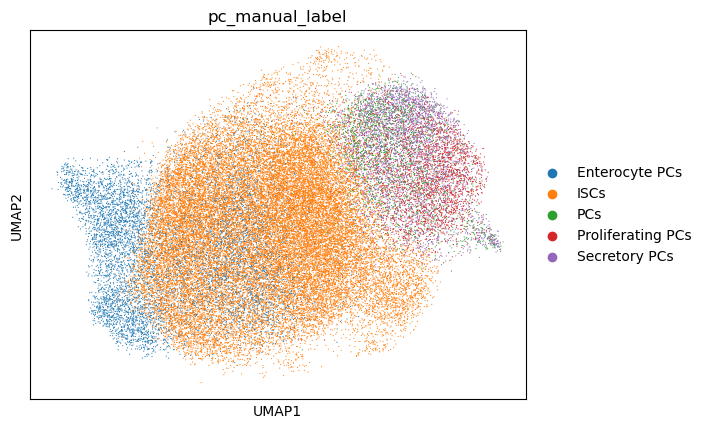

In [11]:
sc.pl.umap(d2_dz_clustered, color = 'pc_manual_label')

In [12]:
#### Our PC label is essentially all Secretory PCs according to this criteria. Therefore, we will not filter the cells based on SOX4, but instead just create two slots, one with 'PC' for the cells and the other with 'Secretory PCs' for the cells

In [13]:
d2_dz_clustered.obs.loc[d2_dz_clustered.obs['manual_label'] == "PCs", 'pc_manual_label'] = "Secretory PCs"

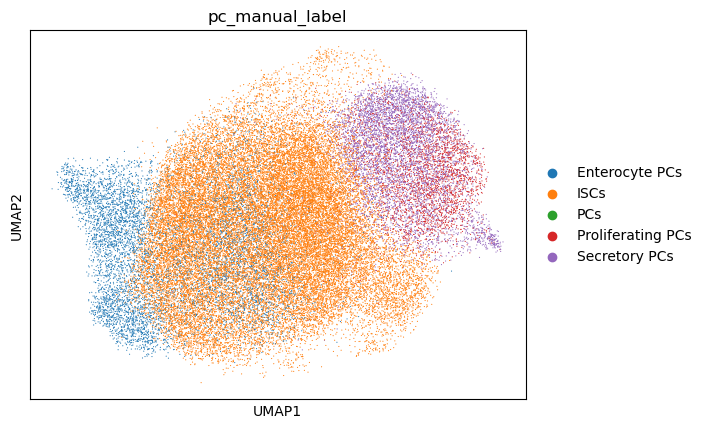

In [14]:
sc.pl.umap(d2_dz_clustered, color = 'pc_manual_label')

In [15]:
#### We still have the legend for the 'PCs' because have them as a category

In [16]:
d2_dz_clustered.obs["pc_manual_label"] = (
    d2_dz_clustered.obs["pc_manual_label"]
    .cat.remove_categories(["PCs"])
)


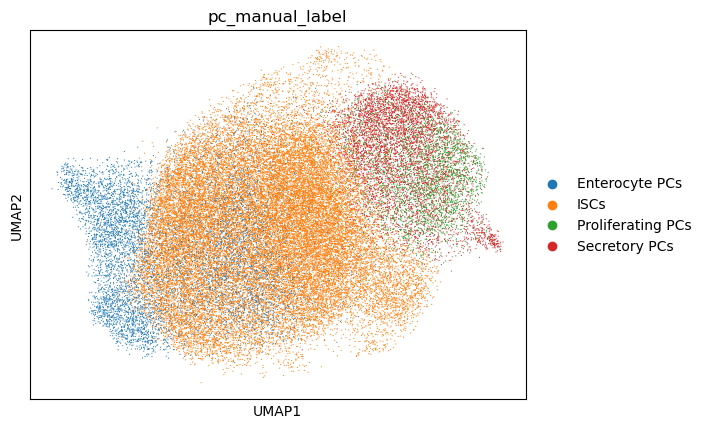

In [17]:
sc.pl.umap(d2_dz_clustered, color = 'pc_manual_label')

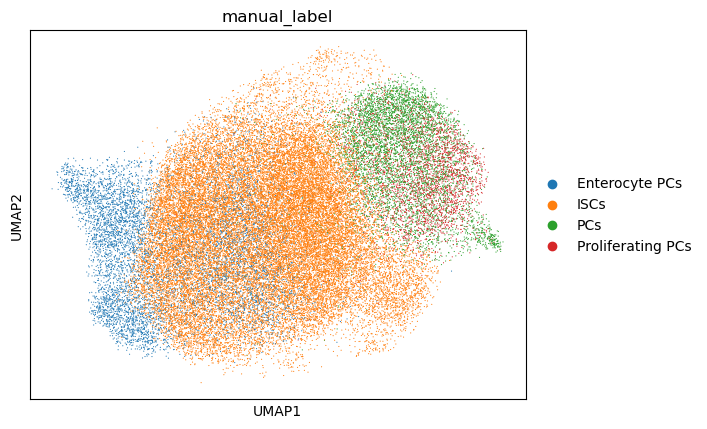

In [18]:
sc.pl.umap(d2_dz_clustered, color = 'manual_label')

#### Now save the object to the manual_labelled_2 folder

In [19]:
os.getcwd()

'/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'

In [20]:
sc.write(str(ANALYSIS_DIR / "data-objects/labelled/d2_dz_manual_labels_2.h5ad"), d2_dz_clustered)